### ANN for regression, Gaming vs Academic Performance

### THIS EXAMPLE CONTAINS A VERY COMMON OPTIMIZATION METHOD IN BASIC ANN REGRESSION - BatchNormalization and regularization, see the neural network structure part for details!

#### Imports / modules

In [1]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

#### Loading the dataset

In [2]:
# load the csv-file to pandas DataFrame
df = pd.read_csv("Gaming_Academic_Performance_updated.csv")

In [3]:
# deep learning / neural network-wise, this is a small dataset
len(df)

8000

In [4]:
# quickly check the first few rows of data
# to see what we have here
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [5]:
# drop Nstudent_id field since it is not required
df.drop(columns=['student_id'], inplace=True)

In [6]:
print(df.dtypes)

age                   int64
gender                  str
gaming_hours        float64
study_hours         float64
sleep_hours         float64
attendance          float64
gaming_genre            str
social_activity     float64
device_usage        float64
reaction_time_ms    float64
addiction_score     float64
stress_level            str
grades              float64
dtype: object


### Few more checks for data, any missing values or duplicates

In [7]:
# it seems we don't have any missing values
df.isna().sum()

age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

In [8]:
# no duplicates either, it seems
int(df.duplicated().sum())

0

### Handling the variables

*Type 1: Boolean categories*

In [9]:
# No boolean variables here

*Type 2: Ordinal categories*

In [10]:
# Check value counts for stress_level before modifying ordinal categories
df['stress_level'].value_counts()

stress_level
Medium    4247
Low       2743
High      1010
Name: count, dtype: int64

In [11]:
# Map stress_level - Ordinal categories
category_mapper = {
'High': 2,
'Medium': 1,
'Low': 0
}
df['stress_level'] = df['stress_level'].replace(category_mapper)

df.head()

,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,0,86.459555
1,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,1,98.230000
2,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,2,90.560000
3,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,0,32.670000
4,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,0,58.710000


*Type 3: Nominal categories*

In [12]:
# Check value counts for gender before modifying ordinal categories
df['gender'].value_counts()

gender
Male      3904
Female    3803
Other      293
Name: count, dtype: int64

In [13]:
# this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ['gender']

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)
df.head()



,age,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gender_Female,gender_Male,gender_Other
0,22,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,0,86.459555,0,1,0
1,19,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,1,98.230000,0,1,0
2,23,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,2,90.560000,1,0,0
3,20,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,0,32.670000,1,0,0
4,22,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,0,58.710000,1,0,0


In [14]:

# we can always remove EXACTLY ONE option per variable when we use OneHotEncoder
df = df.drop("gender_Other", axis=1)

In [15]:
df

,age,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gender_Female,gender_Male
0,22,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,0,86.459555,0,1
1,19,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,1,98.230000,0,1
2,23,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,2,90.560000,1,0
3,20,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,0,32.670000,1,0
4,22,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,0,58.710000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,24,6.33,5.09,4.83,63.74,FPS,4.11,9.96,231.33,11.14,0,35.110000,0,1
7996,22,5.77,6.09,6.23,84.37,FPS,3.42,11.19,254.13,10.66,0,60.800000,1,0
7997,20,2.87,8.51,8.62,67.30,FPS,2.36,6.40,305.00,6.42,1,90.280000,0,1
7998,22,0.98,2.99,7.29,61.13,FPS,2.02,4.57,325.36,2.14,1,56.330000,1,0


In [16]:
# Check value counts for gaming_genre before modifying ordinal categories
df['gaming_genre'].value_counts()

gaming_genre
FPS       3187
RPG       2408
Casual    2405
Name: count, dtype: int64

In [17]:
# this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ['gaming_genre']

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)
df.head()



,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gender_Female,gender_Male,gaming_genre_Casual,gaming_genre_FPS,gaming_genre_RPG
0,22,7.23,8.78,6.96,91.44,3.25,9.36,235.84,14.69,0,86.459555,0,1,0,1,0
1,19,0.07,8.72,7.63,63.63,1.02,3.21,328.71,2.47,1,98.230000,0,1,1,0,0
2,23,1.73,9.56,4.40,83.26,3.46,5.56,313.61,4.73,2,90.560000,1,0,1,0,0
3,20,6.62,1.68,7.83,75.04,1.46,11.78,241.84,14.54,0,32.670000,1,0,0,0,1
4,22,5.36,5.83,5.55,65.57,1.01,8.23,249.31,12.48,0,58.710000,1,0,0,1,0


In [18]:
# we can always remove EXACTLY ONE option per variable when we use OneHotEncoder
df = df.drop("gaming_genre_Casual", axis=1)

#### X/y -split

In [19]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop("grades", axis=1)

# have only the target variable here (dependent variable)
y = df['grades']

#### Train/test/validation -split

In [20]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

#### Create a neural network structure

In [21]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape
# output layer in regression is always 1 node without activation function

# let's try some common optimization approaches

# neural networks often need at least a normalization layer
# so that it updates all weight values fairly 
# typically the original dataset has various scales of numbers
# which confuses neural network while it's training itself
# luckily we have the BatchNormalization -layer in Keras!

# regularization is often beneficial in neural networks as well
# but Wit's usually better to apply this a bit later
# once you know approximately a working neural network structure for your data

# there are three alternatives for kernel regulaizer => L1, L2 and L1/L2
# you just have to experiment to know which regulazier best suits your model
model = keras.Sequential(
    [
        layers.BatchNormalization(input_shape=(variable_amount,)),
        layers.Dense(16, activation="relu", kernel_regularizer=keras.regularizers.l1(l1=0.1)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
# loss-function for regression is mse (mean squared error)
model.compile(optimizer='adam', loss='mse')

model.summary()

c:\Users\Gayani\Deep_Learning\Deep_Learning\.venv\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:181: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,385 (5.41 KB)

 Trainable params: 1,357 (5.30 KB)

 Non-trainable params: 28 (112.00 B)

#### Train the neural network

In [22]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=100, validation_data=(X_val, y_val))

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3113.4172 - val_loss: 492.0153
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 257.1078 - val_loss: 148.0065
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 150.5831 - val_loss: 109.1846
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 125.6516 - val_loss: 97.4442
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 118.2770 - val_loss: 86.4929
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 111.6140 - val_loss: 81.9029
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 102.5105 - val_loss: 77.5720
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 101.2527 - val_loss: 73.9390
Epoch 9/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 97.4279 - val_loss: 72.5794
Epoch 10/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 93.3568 - val_loss: 71.0073
Epoch 11/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 91.9626 - val_loss: 69.5759
Epoch 1

#### Training metrics in order to see if the model trained an works well

<Axes: >

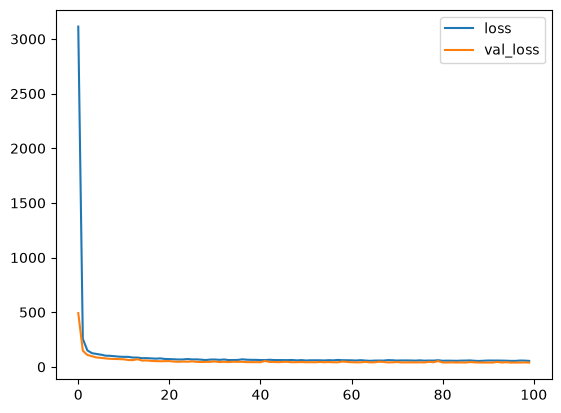

In [23]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

<li>I retrained the model with 100 epochs instead of 1200, because the earlier loss curves were flat after a few dozen epochs. In the new run, both the training loss and the validation loss dropped quickly in the first few epochs and then stayed stable. The validation loss does not rise above the training loss, so there is no sign of overfitting. </li>

In [24]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
38.791568756103516

Train data evaluation:
38.45966720581055


#### Error metrics

In [25]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Test True Y,Model Predictions
0,53.880000,55.614201
1,33.260000,29.175562
2,80.180000,78.662476
3,98.120000,97.741158
4,59.001099,56.796509
...,...,...
1195,63.727091,75.662727
1196,72.110000,72.557930
1197,100.000000,91.480354
1198,89.020000,95.982719


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

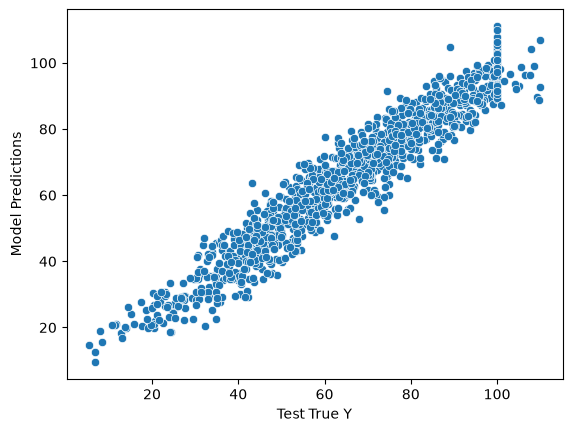

In [26]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

<li>The points on the scatter plot go up along a diagonal line. This means that when the true value is higher, the model's prediction is higher too, so the model has learned the main pattern in the data.

Most predictions are off by about 10 units or less, and the spread is about the same across the whole range.

The model plays it safe at the ends. For very low true values it guesses a bit too high, and for very high true values it guesses a bit too low.

There is also a vertical line of points at 100. This probably means that 100 is the maximum value in the data, so many rows have exactly that value.</li>

In [27]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2))

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2))

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
4.78

MSE
36.02 ^2

RMSE:
6.0

R-squared:
0.93

Explained variance score:
0.93


<li>MAE 4.78: on average, the model's grade prediction is off by about 4.8 points.</li>
<li>MSE 36.02: the average squared error</li>
<li>MSE 6.0: a typical error is about 6 grade points. It is higher than MAE because it penalizes the few large misses more.</li>
<li>R² 0.93: the model explains 93% of the variation in grades. Values close to 1 are very good.</li>
<li>Explained variance 0.93: it equals R², which means the model is not consistently predicting too high or too low.</li>

C:\Users\Gayani\AppData\Local\Temp\ipykernel_28400\3124900743.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - test_predictions))


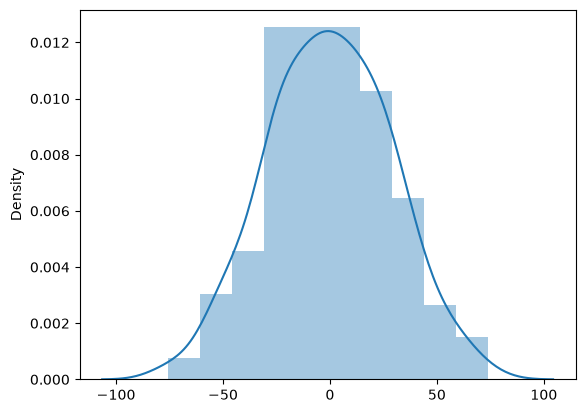

In [28]:
# if the prediction distribution are far from normal distribution
# then the model is not probably good enough
# distplot is deprecating in future pandas-version
# unfortunately, there's no exact alternative to do this plot at the moment
sns.distplot((y_test - test_predictions))
plt.show()
plt.close()

#### Try model in practice (with a new imaginary house)

In [29]:
# just to quickly check what support variables we should include
# in the tester_row -part below
X.columns

Index(['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
       'social_activity', 'device_usage', 'reaction_time_ms',
       'addiction_score', 'stress_level', 'gender_Female', 'gender_Male',
       'gaming_genre_FPS', 'gaming_genre_RPG'],
      dtype='str')

In [ ]:
# print a few example rows so we can test with
# the tester row below
df.head(3)

,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gender_Female,gender_Male,gaming_genre_FPS,gaming_genre_RPG
0,22,7.23,8.78,6.96,91.44,3.25,9.36,235.84,14.69,0,86.459555,0,1,1,0
1,19,0.07,8.72,7.63,63.63,1.02,3.21,328.71,2.47,1,98.230000,0,1,0,0
2,23,1.73,9.56,4.40,83.26,3.46,5.56,313.61,4.73,2,90.560000,1,0,0,0


In [31]:
# let's try with some new imaginary data
# this example uses the Gaming vs Academic Performance dataset
# modify this as needed regarding your own dataset
tester_row = {
    'age': 22,
    'gaming_hours': 5.5,
    'study_hours': 7.0,
    'sleep_hours': 7.0,
    'attendance': 85.0,
    'social_activity': 3.0,
    'device_usage': 7.0,
    'reaction_time_ms': 250.0,
    'addiction_score': 10.0,
    
    'stress_level': 1,       # Low=0, Medium=1, High=2
    
    'gender_Female': 1,      # Female=1, Male=0
    'gender_Male': 0,
    
    'gaming_genre_FPS': 1,   # FPS=1, RPG=0, Casual=0
    'gaming_genre_RPG': 0
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

In [ ]:
# get the prediction from the model and print out the result
result = model.predict(tester_row)[0]

print()
print(f"Predicted grade:")
print(f" {round(float(result[0]), 2)}")
print("----------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

Predicted grade:
$ 73.16
----------------
